### 1.Load data

In [ ]:
import scanpy as sc # cross celltype predict
import scresid
# import pertpy as pt # download dataset
import warnings
warnings.filterwarnings('ignore')
adata = sc.read_h5ad('./data/Srivatsan.h5ad')
adata

AnnData object with n_obs × n_vars = 98437 × 58347
    obs: 'hash_UMI_counts', 'dose_value', 'perturbation', 'dose_value_2', 'perturbation_2', 'cell_line', 'plate_id', 'well_id', 'celltype', 'cancer', 'disease', 'tissue_type', 'organism', 'perturbation_type', 'perturbation_type_2', 'nperts', 'ncounts', 'ngenes', 'percent_mito', 'percent_ribo', 'chembl-ID'
    var: 'ensembl_id', 'ncounts', 'ncells'

In [2]:
adata = scresid.adata_process(adata, 
                      # n_top_genes=2000
                      )

Filter cells with min_genes=200...
Filter genes with min_cells=10...
Normalize per cell...
Apply log1p to adata...
Scale with max_value=10...
Compute highly variable genes with n_top_genes=6000...
Save highly variable genes to adata...
Convert adata to DataFrame...
Save DataFrame to X of adata....
Preprocess completed.


In [3]:
adata.obs.rename(columns={'perturbation': 'condition'}, inplace=True) # Srivatsan
adata.obs.rename(columns={'cell_line': 'cell_type'}, inplace=True)
adata.obs['condition'].replace({"PDH.inhibitor": "stimulated"}, inplace=True)
adata.obs['condition'].replace({"ACLY.inhibitor": "stimulated"}, inplace=True)
adata.obs['condition'].replace({"ACSS2.inhibitor": "stimulated"}, inplace=True)
adata.obs['condition'].replace({"Citrate": "stimulated"}, inplace=True)
adata.obs['condition'].replace({"Pyruvate": "stimulated"}, inplace=True)
adata.obs['condition'].replace({"Acetate": "stimulated"}, inplace=True)
adata.obs['condition'].replace({"Chloride": "stimulated"}, inplace=True)

In [4]:
adata = sc.AnnData(adata.X, obs=adata.obs.copy(), var=adata.var.copy())
adata.obs_names_make_unique()
print(adata)
print('\n', adata.obs['condition'].value_counts())
print('\n', adata.obs['cell_type'].value_counts())

AnnData object with n_obs × n_vars = 98403 × 6000
    obs: 'hash_UMI_counts', 'dose_value', 'condition', 'dose_value_2', 'perturbation_2', 'cell_type', 'plate_id', 'well_id', 'celltype', 'cancer', 'disease', 'tissue_type', 'organism', 'perturbation_type', 'perturbation_type_2', 'nperts', 'ncounts', 'ngenes', 'percent_mito', 'percent_ribo', 'chembl-ID', 'n_genes', 'n_counts'
    var: 'ensembl_id', 'ncounts', 'ncells', 'n_cells', 'mean', 'std', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'

 condition
stimulated    81846
control       16517
Name: count, dtype: int64

 cell_type
A549    49299
MCF7    49064
Name: count, dtype: int64


### 2.Build and train models

In [5]:
model = scresid.SCRESID(input_dim=adata.n_vars, device='cuda:0')
model = model.to(model.device)
# key_dic varies with the adata
key_dic = {'condition_key': 'condition',
           'cell_type_key': 'cell_type',
           'ctrl_key': 'control',
           'stim_key': 'stimulated',
           'pred_key': 'predict',
           }


In [ ]:
cell_to_pred = 'A549' # MCF7
# The training set does not contain the type of data to be predicted after the perturbation
train = adata[~((adata.obs[key_dic['cell_type_key']] == cell_to_pred) &
               (adata.obs[key_dic['condition_key']] == key_dic['stim_key']))]
model.train_SCRESID(train, batch_size=512, lr=5e-5, epochs=100)

Training Epoch 99: 100%|██████████| 100/100 [02:42<00:00,  1.63s/it]


### 3.Predict

In [7]:
adata_to_pred = adata[((adata.obs[key_dic['cell_type_key']] == cell_to_pred) &
                       (adata.obs[key_dic['condition_key']] == key_dic['ctrl_key']))]
pred = model.predict(train_adata=train,
                     cell_to_pred=cell_to_pred,
                     key_dic=key_dic,
                     ratio=0.05 # The ratio need to vary with the size of dataset
                     )  
print(pred)

Get adata of A549 and control...
Get adata of without A549 and control...
Get stimulated adata of condition...
Get latent adata of control and stimulated...
Compute distance of stimulated and control by POT...
Compute G of stimulated and control by emd in POT...
Match max idx from G...
Get delta list of matched stimulated and control...
Get latent adata of A549...
Compute cosine similarity with latent adata of A549 and control...
Select top control with ratio 0.05...
Normalize weights of 482 top cosine similarity...
Compute delta of predict...
Decode predict latent embedding...
Create predict adata and save key predict...
Predict process completed.
AnnData object with n_obs × n_vars = 6890 × 6000
    obs: 'hash_UMI_counts', 'dose_value', 'condition', 'dose_value_2', 'perturbation_2', 'cell_type', 'plate_id', 'well_id', 'celltype', 'cancer', 'disease', 'tissue_type', 'organism', 'perturbation_type', 'perturbation_type_2', 'nperts', 'ncounts', 'ngenes', 'percent_mito', 'percent_ribo', 'c

### 4.Evaluation

PCA cluster results...


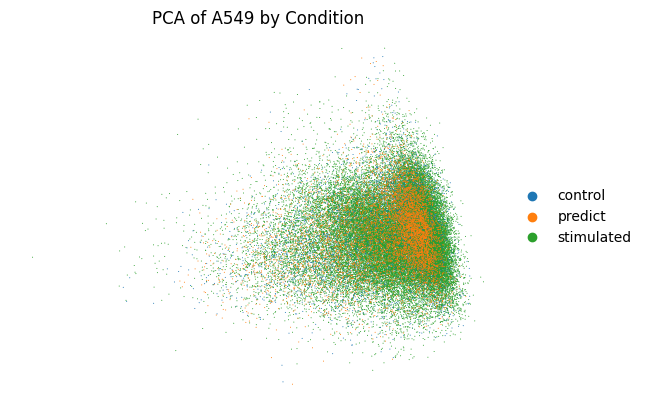

Compute rank_genes_groups...
Select common DEGS...
Common DEGs:  2
Regression plot of mean...


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


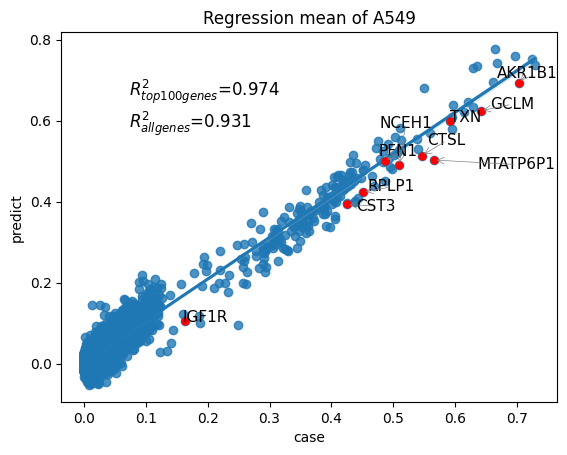

R2 mean of all genes 0.931, top genes 0.974
Regression plot of var...


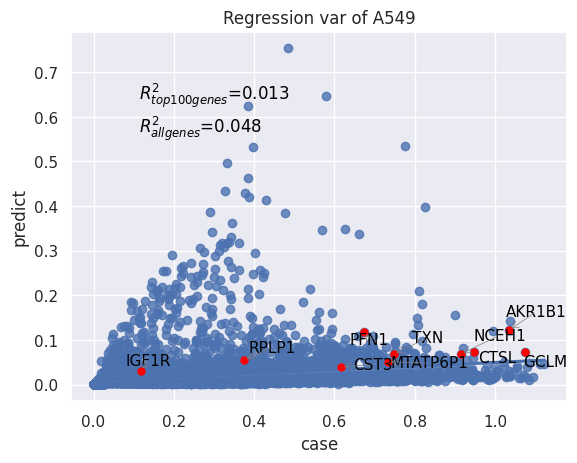

R2 var of all genes 0.048, top genes 0.013
Plot violin graph of first gene AKR1B1...


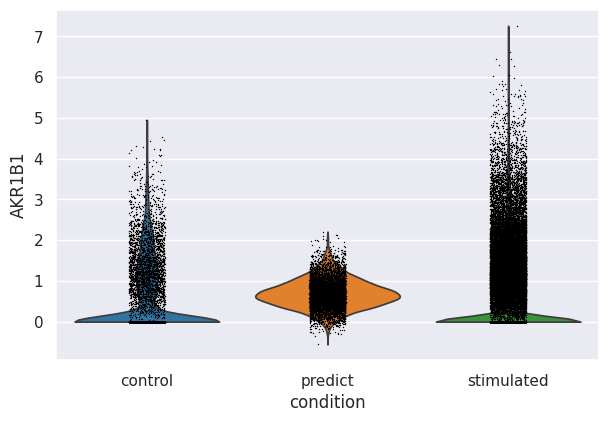

Plot violin graph of second gene MTATP6P1...


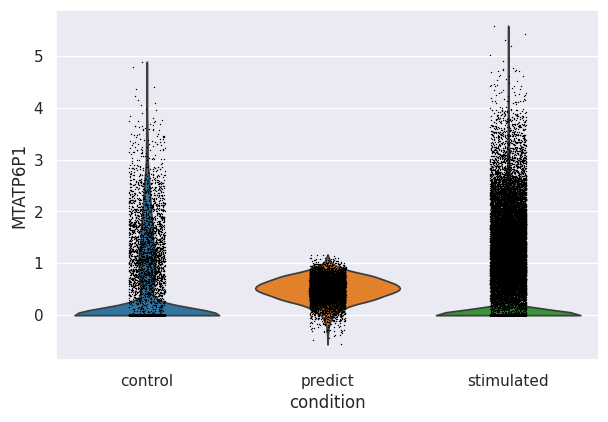

Plot violin graph of third gene PFN1...


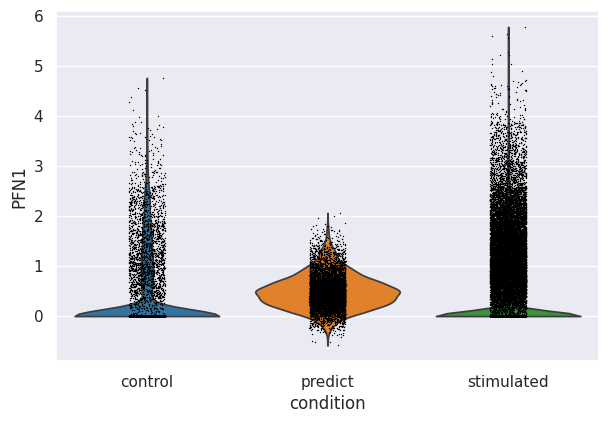

Compute DEGS contrast...
Plot 25 genes of eval_adata...


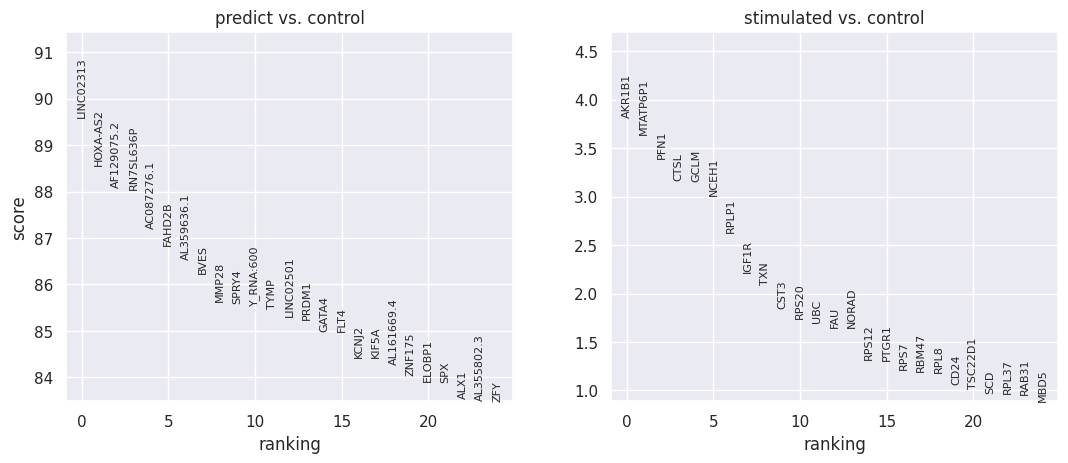

Dotplot of the first 20 genes...


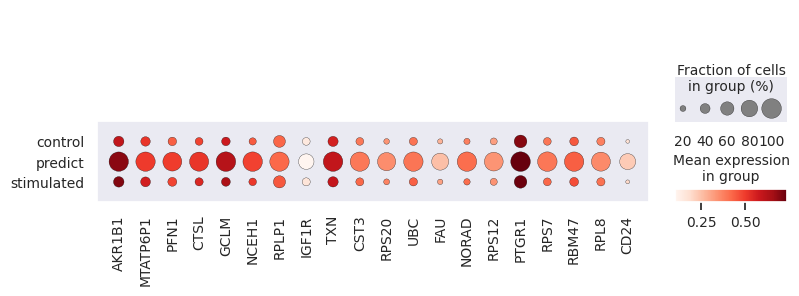

In [8]:
ground_truth = adata[(adata.obs[key_dic['cell_type_key']] == cell_to_pred)]
eval_adata = ground_truth.concatenate(pred)
scresid.evaluate(eval_adata=eval_adata, 
                cell_type=cell_to_pred, 
                key_dic=key_dic
                )
